# 03_RQ3_Preprocessing_Study
Objective and methodology.

# ============================================
# RQ3: Effect of Preprocessing
# ============================================

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score



# ============================================
# 2. Setup
# ============================================

In [32]:
os.makedirs('outputs', exist_ok=True)

# ============================================
# 3. Load Dataset
# ============================================

In [33]:
df = pd.read_csv('marketing_and_product_performance.csv')

# ============================================
# 4. Feature Engineering
# ============================================

In [34]:
df['Conversion_Rate'] = df['Conversions'] / df['Clicks']
df['Conversion_Rate'] = df['Conversion_Rate'].replace([np.inf, -np.inf], 0)

# Create Target
def categorize(rate):
    if rate < 0.02:
        return 0
    elif rate < 0.05:
        return 1
    else:
        return 2

df['Target'] = df['Conversion_Rate'].apply(categorize)

# Prepare Data
X = df.drop(columns=['Target', 'Conversion_Rate'])
y = df['Target']

# ============================================
# 5. Prepare Data 
# ============================================


In [35]:
X = df.drop(columns=['Target', 'Conversion_Rate'])
y = df['Target']

# Encode once
X = pd.get_dummies(X, drop_first=True)

# 🔥 LIMIT FEATURES (important fix)
if X.shape[1] > 50:
    X = X.iloc[:, :50]
# Split once
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ============================================
# 6. Evaluation Function
# ============================================

In [36]:
model = LogisticRegression(
    max_iter=300,
    solver='saga',
    n_jobs=-1
)

def run_model(X_tr, X_te, name):
    model = DecisionTreeClassifier(max_depth=5, random_state=42)

    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    # AUC (handle multiclass)
    try:
        y_prob = model.predict_proba(X_te)
        auc = roc_auc_score(pd.get_dummies(y_test), y_prob, multi_class='ovr')
    except:
        auc = 0  # fallback if not available

    print(f"{name} done")

    return [name, acc, prec, rec, f1, auc]

# ============================================
# 7. Preprocessing Scenarios
# ============================================


In [37]:
results = []

# 1. Raw
results.append(run_model(X_train, X_test, "Raw"))

# 2. Imputation
imp = SimpleImputer(strategy='mean')
X_train_imp = imp.fit_transform(X_train)
X_test_imp = imp.transform(X_test)

results.append(run_model(X_train_imp, X_test_imp, "Imputation"))

# 3. Scaling
scaler = StandardScaler()
X_train_scale = scaler.fit_transform(X_train)
X_test_scale = scaler.transform(X_test)

results.append(run_model(X_train_scale, X_test_scale, "Scaling"))

# 4. Full
X_train_full = imp.fit_transform(X_train)
X_test_full = imp.transform(X_test)

X_train_full = scaler.fit_transform(X_train_full)
X_test_full = scaler.transform(X_test_full)

results.append(run_model(X_train_full, X_test_full, "Full Pipeline"))



Raw done
Imputation done
Scaling done
Full Pipeline done


# ============================================
# 8. Results Table
# ============================================


In [40]:
results_df = pd.DataFrame(results, columns=[
    "Preprocessing", "Accuracy", "Precision", "Recall", "F1-score", "AUC"
])

print("\nPreprocessing Impact Results:\n")
print(results_df)

# Save table
results_df.to_csv('RQ3_outputs/RQ3_Preprocessing_Results.csv', index=False)



Preprocessing Impact Results:

   Preprocessing  Accuracy  Precision  Recall  F1-score       AUC
0            Raw    0.9775   0.977584  0.9775  0.977532  0.993794
1     Imputation    0.9775   0.977584  0.9775  0.977532  0.993794
2        Scaling    0.9775   0.977584  0.9775  0.977532  0.993794
3  Full Pipeline    0.9775   0.977584  0.9775  0.977532  0.993794


# ============================================
# 9. Visualization
# ============================================

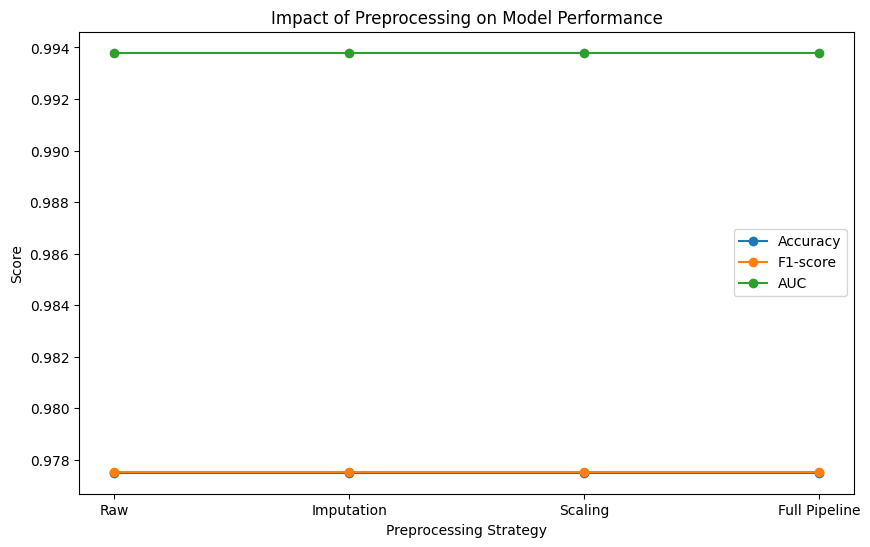

In [41]:
plt.figure(figsize=(10,6))

plt.plot(results_df["Preprocessing"], results_df["Accuracy"], marker='o', label="Accuracy")
plt.plot(results_df["Preprocessing"], results_df["F1-score"], marker='o', label="F1-score")
plt.plot(results_df["Preprocessing"], results_df["AUC"], marker='o', label="AUC")

plt.title("Impact of Preprocessing on Model Performance")
plt.xlabel("Preprocessing Strategy")
plt.ylabel("Score")
plt.legend()

plt.savefig('RQ3_outputs/RQ3_Preprocessing_Impact.pdf')
plt.show()